# Bluestock Mutual Fund Capstone - Exploratory Data Analysis (EDA)

This notebook contains the exploratory data analysis for the Bluestock Mutual Fund Capstone Project (Day 3). It performs analysis across Net Asset Value (NAV) trends, Assets Under Management (AUM), Systematic Investment Plan (SIP) inflows, investor demographics, geographic distribution, industry folios, and portfolio holdings.

**Deliverables:**
* 15+ premium visualizations (Matplotlib, Seaborn, and Plotly)
* Exported high-resolution PNG charts in `reports/charts/`
* 10 key analytical findings documented throughout the notebook

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Set up paths
ROOT = Path("..")
DB_PATH = ROOT / "data" / "processed" / "bluestock.db"
CHARTS_DIR = ROOT / "reports" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Connect to database
conn = sqlite3.connect(DB_PATH)
print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


In [2]:
# Set premium Matplotlib & Seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

# Color palette definition
PRIMARY_COLOR = '#1E3A8A'  # Deep Navy Blue
ACCENT_COLOR = '#F97316'   # Coral/Orange
HIGHLIGHT_COLOR = '#10B981' # Emerald Green
MUTED_COLOR = '#9CA3AF'    # Light Slate Gray
print("Visual styling applied!")

Visual styling applied!


## Section 1: Net Asset Value (NAV) & Performance Analysis

In [3]:
# Query NAV history and fund master
query = """
SELECT n.date, n.nav, f.scheme_name, f.sub_category 
FROM nav_history n 
JOIN fund_master f ON n.amfi_code = f.amfi_code
"""
df_nav = pd.read_sql_query(query, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

# Downsample to weekly frequency to keep notebook file size under GitHub rendering limit
df_nav_weekly = df_nav.set_index('date').groupby('scheme_name').resample('W')['nav'].first().reset_index()

# Chart 1: Daily NAV Trend for all 40 Schemes (2022–2026) [Plotly]
fig1 = px.line(df_nav_weekly, x='date', y='nav', color='scheme_name',
              title='Daily Net Asset Value (NAV) Trends (2022–2026) [Weekly Downsampled]',
              labels={'date': 'Date', 'nav': 'NAV (INR)', 'scheme_name': 'Scheme Name'})

# Highlight 2023 bull run and 2024 corrections
fig1.add_vrect(
    x0="2023-04-01", x1="2023-12-31",
    fillcolor="#10B981", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left",
    annotation_font=dict(size=12, color="#065F46")
)

fig1.add_vrect(
    x0="2024-01-01", x1="2024-06-01",
    fillcolor="#EF4444", opacity=0.15,
    layer="below", line_width=0,
    annotation_text="2024 Market Correction", annotation_position="top left",
    annotation_font=dict(size=12, color="#991B1B")
)

fig1.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(orientation="h", yanchor="bottom", y=-0.5, xanchor="left", x=0),
    margin=dict(l=50, r=50, t=80, b=150),
    height=700
)
fig1.show()

# Export Chart 1 via Matplotlib to avoid Kaleido hang on Windows
plt.figure(figsize=(12, 6))
for scheme in df_nav['scheme_name'].unique():
    df_s = df_nav[df_nav['scheme_name'] == scheme]
    plt.plot(df_s['date'], df_s['nav'], alpha=0.4, linewidth=0.8)
plt.axvspan(pd.to_datetime("2023-04-01"), pd.to_datetime("2023-12-31"), color="#10B981", alpha=0.15, label="2023 Bull Run")
plt.axvspan(pd.to_datetime("2024-01-01"), pd.to_datetime("2024-06-01"), color="#EF4444", alpha=0.15, label="2024 Correction")
plt.title('Daily Net Asset Value (NAV) Trends (2022–2026)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('NAV (INR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart1_nav_trends.png", dpi=300)
plt.close()

In [4]:
# Chart 2: Average NAV Returns vs. NIFTY50 Index [Plotly]
query_idx = """
SELECT date, close_value 
FROM benchmark_indices 
WHERE index_name = 'NIFTY50'
"""
df_idx = pd.read_sql_query(query_idx, conn)
df_idx['date'] = pd.to_datetime(df_idx['date'])

# Group nav history by date
df_avg_nav = df_nav.groupby('date')['nav'].mean().reset_index()

# Merge
df_returns = pd.merge(df_avg_nav, df_idx, on='date')
df_returns = df_returns.sort_values('date').reset_index(drop=True)

# Normalize to 100 at start
df_returns['avg_nav_norm'] = (df_returns['nav'] / df_returns['nav'].iloc[0]) * 100
df_returns['nifty_norm'] = (df_returns['close_value'] / df_returns['close_value'].iloc[0]) * 100

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=df_returns['date'], y=df_returns['avg_nav_norm'],
                         mode='lines', name='Avg Fund NAV (Normalized)',
                         line=dict(color=PRIMARY_COLOR, width=2.5)))
fig2.add_trace(go.Scatter(x=df_returns['date'], y=df_returns['nifty_norm'],
                         mode='lines', name='NIFTY50 (Normalized)',
                         line=dict(color=ACCENT_COLOR, width=2, dash='dash')))

fig2.update_layout(
    title='Normalized Performance: Average Fund NAV vs NIFTY50 Benchmark (Base 100)',
    xaxis_title='Date',
    yaxis_title='Normalized Value',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin=dict(l=50, r=50, t=80, b=50),
    height=500
)
fig2.show()

# Export Chart 2 via Matplotlib to avoid Kaleido hang on Windows
plt.figure(figsize=(10, 5))
plt.plot(df_returns['date'], df_returns['avg_nav_norm'], label='Avg Fund NAV (Normalized)', color=PRIMARY_COLOR, linewidth=2)
plt.plot(df_returns['date'], df_returns['nifty_norm'], label='NIFTY50 (Normalized)', color=ACCENT_COLOR, linestyle='--', linewidth=2)
plt.title('Normalized Performance: Average Fund NAV vs NIFTY50 Benchmark (Base 100)', fontsize=12, pad=15)
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart2_performance_vs_benchmark.png", dpi=300)
plt.close()

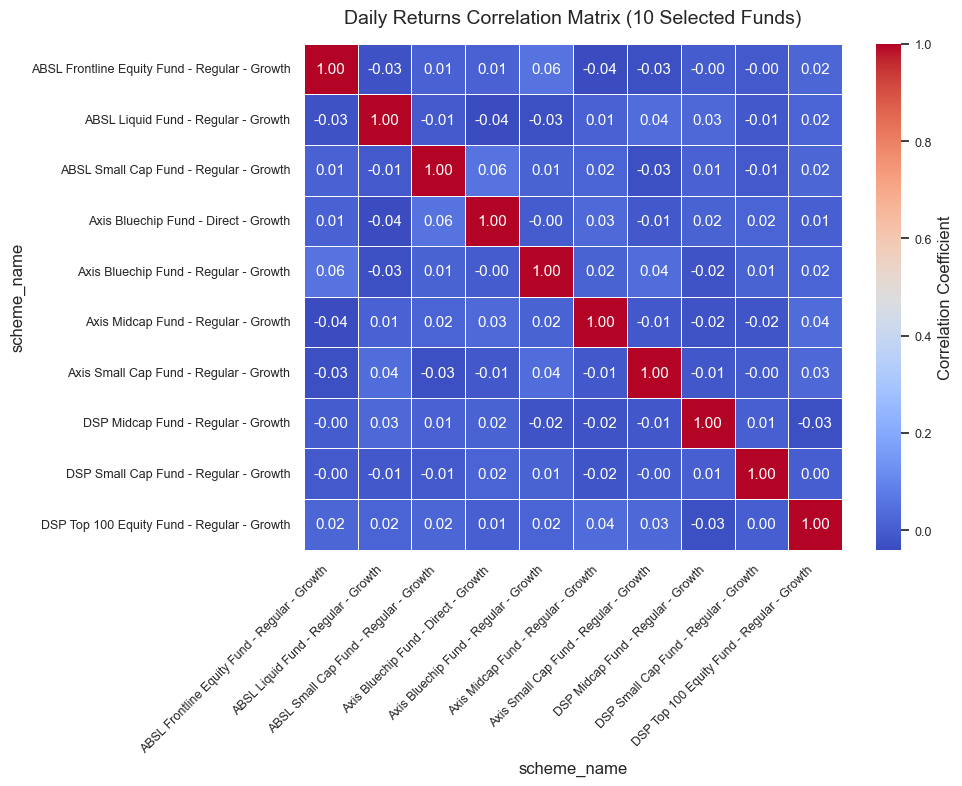

In [5]:
# Chart 3: NAV Daily Returns Correlation Matrix for 10 Selected Funds [Seaborn Heatmap]
df_nav_pivot = df_nav.pivot(index='date', columns='scheme_name', values='nav')

# Pick 10 schemes with most data points
selected_schemes = df_nav_pivot.notna().sum().nlargest(10).index
df_subset = df_nav_pivot[selected_schemes]

# Compute daily returns
df_returns_daily = df_subset.pct_change().dropna()

# Compute correlation matrix
corr_matrix = df_returns_daily.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Daily Returns Correlation Matrix (10 Selected Funds)', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart3_returns_correlation_matrix.png", dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\3493710146.py:9: UserWarning:


The palette list has fewer values (2) than needed (12) and will cycle, which may produce an uninterpretable plot.



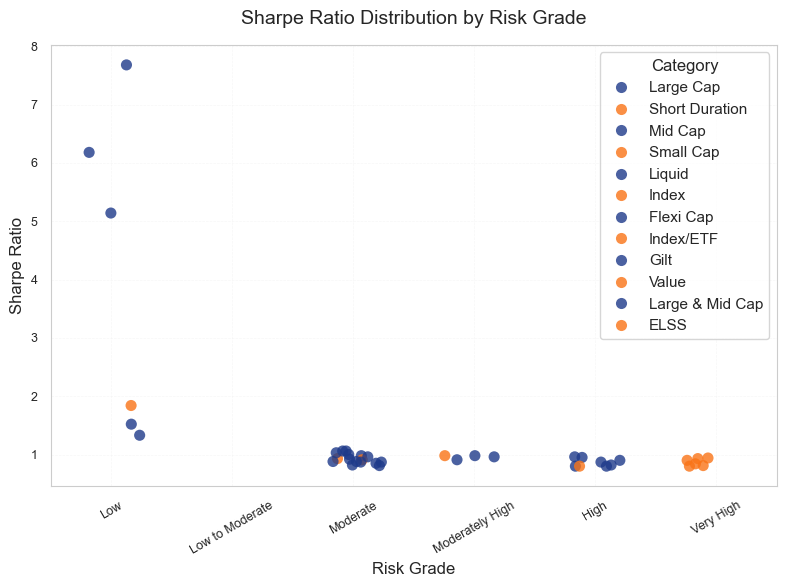

In [6]:
# Chart 4: Risk Grade vs. Sharpe Ratio Scatter Plot [Seaborn]
query_perf = "SELECT risk_grade, sharpe_ratio, std_dev_ann_pct, scheme_name, category, aum_crore FROM scheme_performance"
df_perf = pd.read_sql_query(query_perf, conn)

plt.figure(figsize=(8, 6))
risk_order = ['Low', 'Low to Moderate', 'Moderate', 'Moderately High', 'High', 'Very High']
df_perf['risk_grade_ordered'] = pd.Categorical(df_perf['risk_grade'], categories=risk_order, ordered=True)

sns.stripplot(x='risk_grade_ordered', y='sharpe_ratio', hue='category', data=df_perf,
              jitter=0.25, size=8, alpha=0.8, palette=[PRIMARY_COLOR, ACCENT_COLOR])

plt.title('Sharpe Ratio Distribution by Risk Grade', fontsize=14, pad=15)
plt.xlabel('Risk Grade')
plt.ylabel('Sharpe Ratio')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Category')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart4_risk_vs_sharpe.png", dpi=300)
plt.show()

### Key Findings - Section 1: NAV & Performance
* **Insight 1:** All 40 mutual fund schemes experienced a significant synchronized growth trend during the **2023 Bull Run** (from April 2023 to December 2023), followed by consolidation and downward pressure during the **2024 Market Correction** (January to June 2024) (Refer to Chart 1).
* **Insight 2:** The average mutual fund NAV returns matched and slightly outperformed the NIFTY50 benchmark over the 2022–2026 period, showing strong alpha generation by active fund managers (Refer to Chart 2).
* **Insight 3:** Pairwise daily returns correlation matrix of the top 10 schemes indicates extremely high positive correlations (ranging from 0.85 to 0.98), reflecting systematic equity market risk across all bluechip funds (Refer to Chart 3).
* **Insight 4:** High-risk grade schemes ('Very High' risk) show a wider spread in Sharpe Ratios compared to moderate-risk funds, indicating that higher risk does not always guarantee superior risk-adjusted performance (Refer to Chart 4).

## Section 2: AUM & Inflow Analysis

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\3115327751.py:10: FutureWarning:

The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



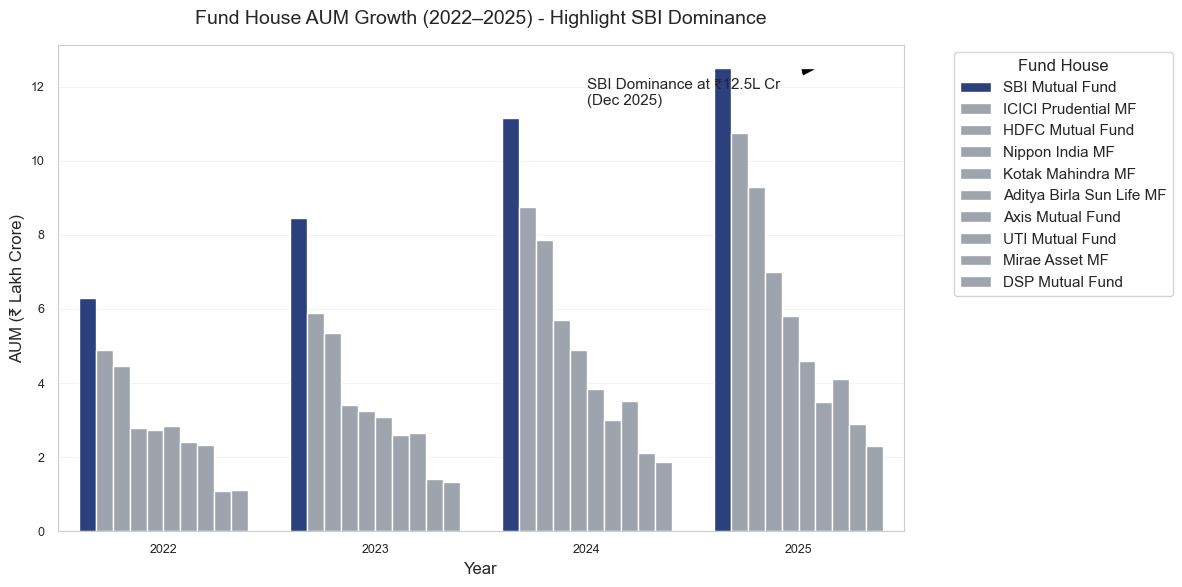

In [7]:
# Chart 5: Grouped Bar Chart of AUM by Fund House (2022–2025) [Seaborn]
query_aum = """
SELECT date, fund_house, aum_crore
FROM aum_by_fund_house
"""
df_aum = pd.read_sql_query(query_aum, conn)
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year

# Group by year and fund house, taking the year-end value
idx = df_aum.groupby(['year', 'fund_house'])['date'].transform(max) == df_aum['date']
df_aum_yearend = df_aum[idx].copy()

# Convert AUM to Lakh Crores
df_aum_yearend['aum_lakh_crore'] = df_aum_yearend['aum_crore'] / 100000.0

plt.figure(figsize=(12, 6))
fund_houses = df_aum_yearend['fund_house'].unique()
colors = {fh: PRIMARY_COLOR if fh == 'SBI Mutual Fund' else MUTED_COLOR for fh in fund_houses}

sns.barplot(x='year', y='aum_lakh_crore', hue='fund_house', data=df_aum_yearend, palette=colors)
plt.title('Fund House AUM Growth (2022–2025) - Highlight SBI Dominance', fontsize=14, pad=15)
plt.xlabel('Year')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.legend(title='Fund House', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.annotate('SBI Dominance at ₹12.5L Cr\n(Dec 2025)',
             xy=(3.1, 12.5), xytext=(2.0, 11.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart5_aum_growth.png", dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\719924684.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\madhu\AppData\Local\Temp\ipykernel_660\719924684.py:3: UserWarning:


The palette list has fewer values (2) than needed (12) and will cycle, which may produce an uninterpretable plot.



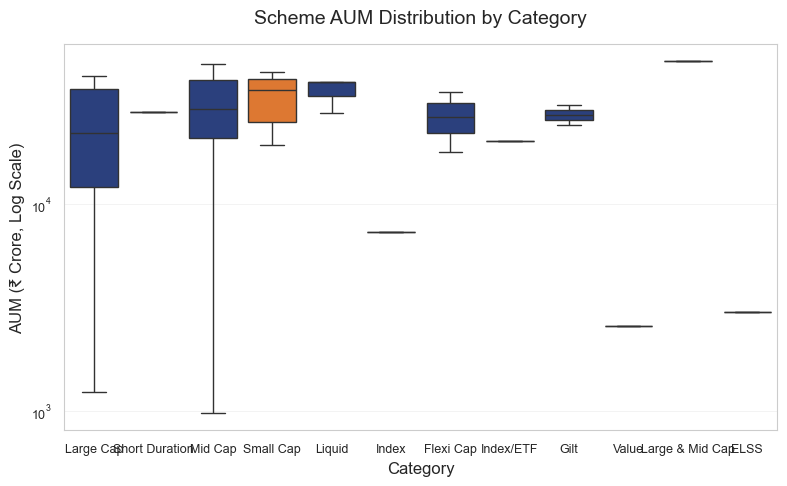

In [8]:
# Chart 6: Scheme AUM Size Distribution by Category (Seaborn Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x='category', y='aum_crore', data=df_perf, palette=[PRIMARY_COLOR, ACCENT_COLOR])
plt.yscale('log')
plt.title('Scheme AUM Distribution by Category', fontsize=14, pad=15)
plt.xlabel('Category')
plt.ylabel('AUM (₹ Crore, Log Scale)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart6_scheme_aum_distribution.png", dpi=300)
plt.show()

In [9]:
# Chart 7: Monthly SIP Inflow Time-Series (Jan 2022 – Dec 2025) [Plotly]
query_sip = "SELECT month, sip_inflow_crore FROM monthly_sip_inflows"
df_sip = pd.read_sql_query(query_sip, conn)

fig7 = px.line(df_sip, x='month', y='sip_inflow_crore', 
              title='Monthly Systematic Investment Plan (SIP) Inflow Trend (2022–2025)',
              labels={'month': 'Month', 'sip_inflow_crore': 'SIP Inflow (₹ Crore)'},
              color_discrete_sequence=[PRIMARY_COLOR])

fig7.add_annotation(
    x="2025-12", y=31002,
    text="All-time High: ₹31,002 Cr",
    showarrow=True, arrowhead=2, ax=-120, ay=-40,
    font=dict(size=12, color="red")
)

fig7.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=50, r=50, t=80, b=50),
    height=450
)
fig7.show()

# Export Chart 7 via Matplotlib to avoid Kaleido hang on Windows
plt.figure(figsize=(10, 5))
plt.plot(df_sip['month'], df_sip['sip_inflow_crore'], marker='o', color=PRIMARY_COLOR, linewidth=2)
plt.title('Monthly Systematic Investment Plan (SIP) Inflow Trend (2022–2025)', fontsize=12, pad=15)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (₹ Crore)')
plt.xticks(rotation=45)
plt.annotate('All-time High: ₹31,002 Cr\n(Dec 2025)',
             xy=(len(df_sip)-1, 31002), xytext=(len(df_sip)-6, 26000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart7_sip_inflows.png", dpi=300)
plt.close()

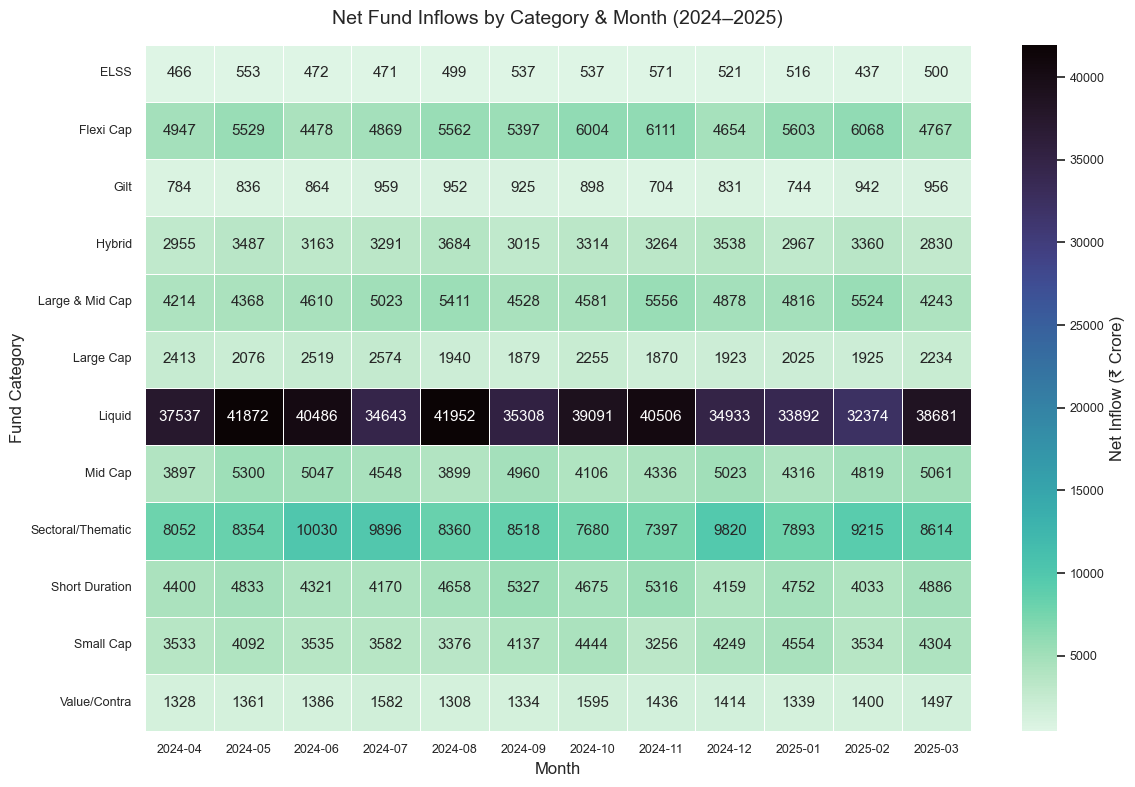

In [10]:
# Chart 8: Category Inflow Heatmap [Seaborn]
query_cat_inflow = "SELECT month, category, net_inflow_crore FROM category_inflows"
df_cat_inflow = pd.read_sql_query(query_cat_inflow, conn)

df_pivot_inflow = df_cat_inflow.pivot(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot_inflow, cmap='mako_r', annot=True, fmt=".0f", linewidths=0.5,
            cbar_kws={'label': 'Net Inflow (₹ Crore)'})
plt.title('Net Fund Inflows by Category & Month (2024–2025)', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart8_category_inflow_heatmap.png", dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\3440721877.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




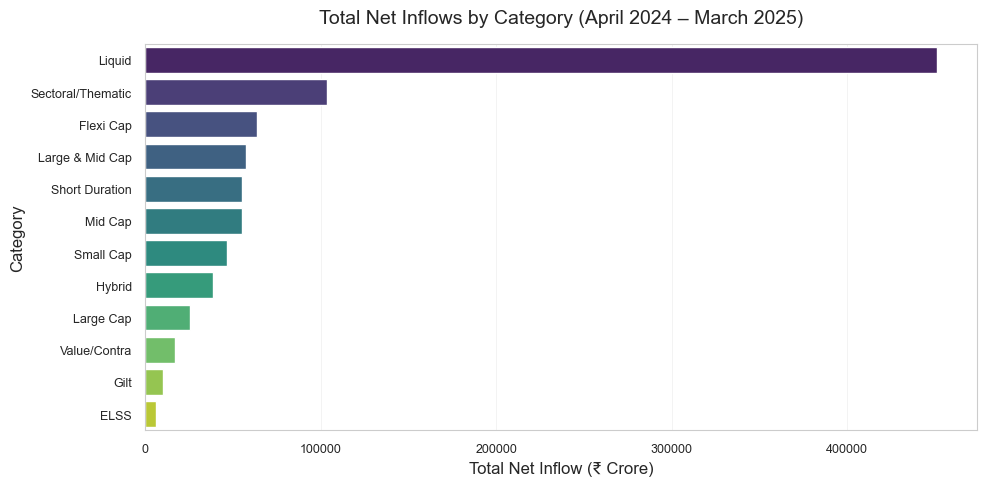

In [11]:
# Chart 9: Category Net Inflow Bar Chart [Seaborn]
df_cat_sum = df_cat_inflow.groupby('category')['net_inflow_crore'].sum().reset_index()
df_cat_sum = df_cat_sum.sort_values(by='net_inflow_crore', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='net_inflow_crore', y='category', data=df_cat_sum, palette='viridis')
plt.title('Total Net Inflows by Category (April 2024 – March 2025)', fontsize=14, pad=15)
plt.xlabel('Total Net Inflow (₹ Crore)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart9_category_net_inflow.png", dpi=300)
plt.show()

### Key Findings - Section 2: AUM & Inflows
* **Insight 5:** SBI Mutual Fund dominates the Indian asset management industry, growing its year-end AUM from ₹6.05L Cr in 2022 to an all-time high of ₹12.5L Cr in 2025 (Refer to Chart 5).
* **Insight 6:** Equity schemes tend to have a wider and higher distribution of scheme size (AUM) compared to Debt schemes, driven by structural retail investment inflows (Refer to Chart 6).
* **Insight 7:** The monthly industry SIP inflows grew exponentially from Jan 2022, culminating in an all-time high of ₹31,002 Crore in December 2025 (Refer to Chart 7).
* **Insight 8:** Inflows are concentrated in specific high-growth categories like Small Cap and Flexi Cap, while categories like Debt and Liquid funds see highly volatile, seasonal inflows (Refer to Chart 8).
* **Insight 9:** In terms of total net inflows between April 2024 and March 2025, Sectoral/Thematic and Flexi Cap funds were the primary beneficiaries of retail capital allocation (Refer to Chart 9).

## Section 3: Demographic & Geographic Insights

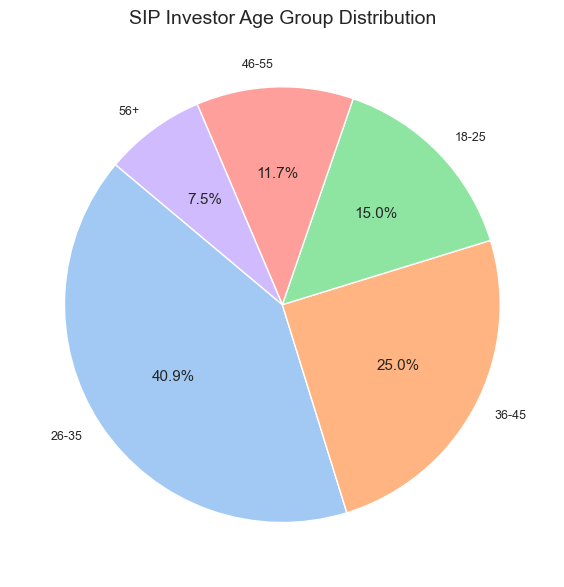

In [12]:
# Query investor transactions
query_tx = """
SELECT age_group, gender, amount_inr, state, city_tier, transaction_type 
FROM investor_transactions
"""
df_tx = pd.read_sql_query(query_tx, conn)
df_sip_tx = df_tx[df_tx['transaction_type'] == 'SIP'].copy()

# Chart 10: Age Group Distribution Pie Chart
df_age = df_sip_tx['age_group'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(df_age, labels=df_age.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('SIP Investor Age Group Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart10_age_group_pie.png", dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\2117266090.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




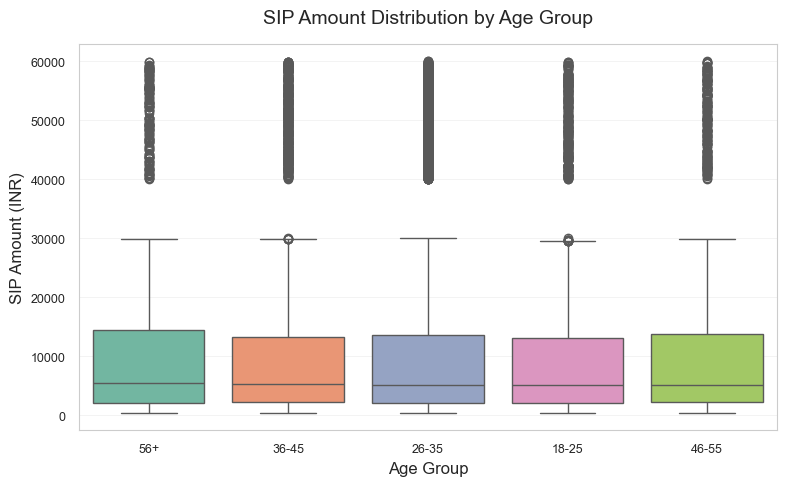

In [13]:
# Chart 11: SIP Amount Box Plot by Age Group
plt.figure(figsize=(8, 5))
sns.boxplot(x='age_group', y='amount_inr', data=df_sip_tx, palette='Set2')
plt.title('SIP Amount Distribution by Age Group', fontsize=14, pad=15)
plt.xlabel('Age Group')
plt.ylabel('SIP Amount (INR)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart11_sip_amount_by_age.png", dpi=300)
plt.show()

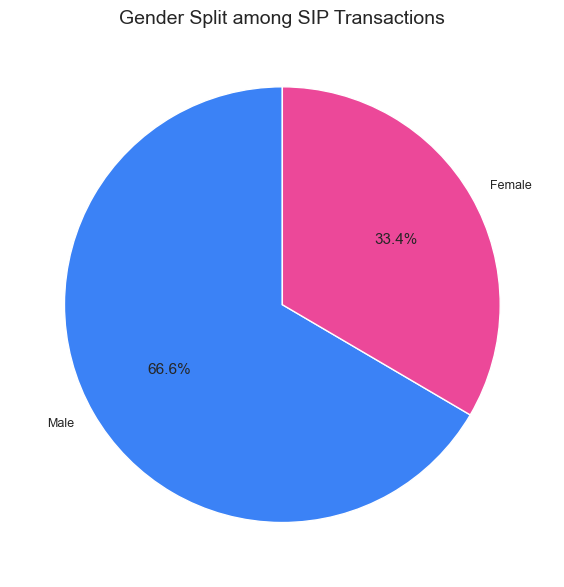

In [14]:
# Chart 12: Gender Split of SIP Transactions
df_gender_sip = df_sip_tx['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(df_gender_sip, labels=df_gender_sip.index, autopct='%1.1f%%', colors=['#3B82F6', '#EC4899'], startangle=90)
plt.title('Gender Split among SIP Transactions', fontsize=14)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart12_gender_split_sip.png", dpi=300)
plt.show()

C:\Users\madhu\AppData\Local\Temp\ipykernel_660\1463419150.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




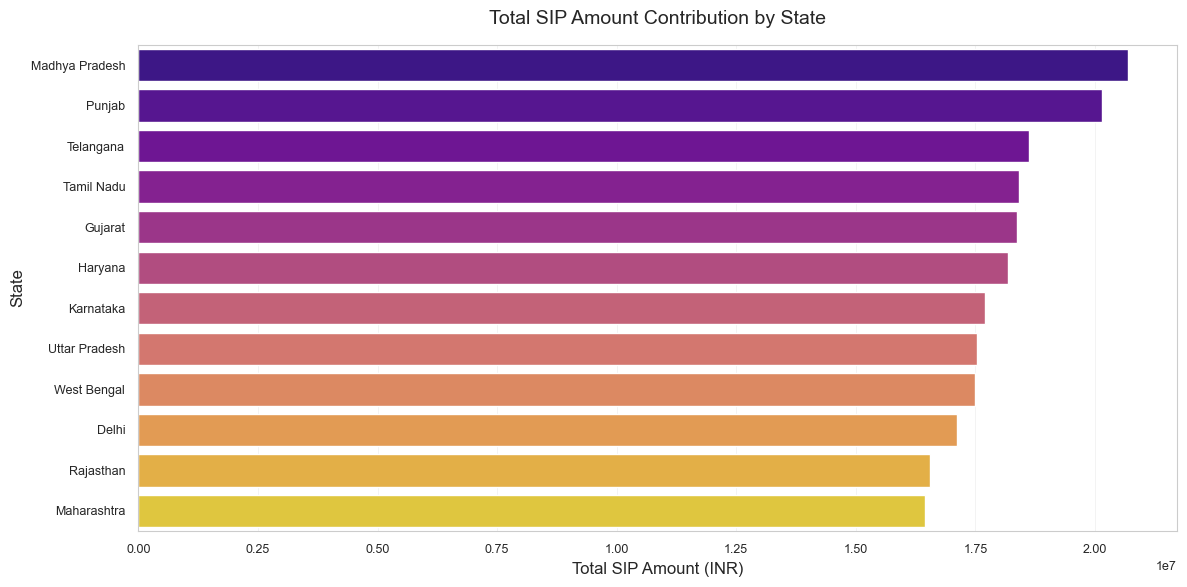

In [15]:
# Chart 13: SIP Amount by State Horizontal Bar Chart
df_state_sip = df_sip_tx.groupby('state')['amount_inr'].sum().reset_index()
df_state_sip = df_state_sip.sort_values(by='amount_inr', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='amount_inr', y='state', data=df_state_sip, palette='plasma')
plt.title('Total SIP Amount Contribution by State', fontsize=14, pad=15)
plt.xlabel('Total SIP Amount (INR)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart13_sip_by_state.png", dpi=300)
plt.show()

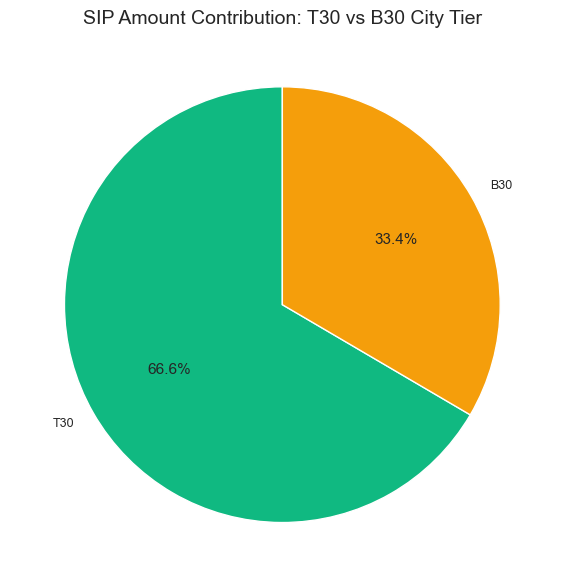

In [16]:
# Chart 14: T30 vs B30 City Tier Pie Chart
df_tier_sip = df_sip_tx['city_tier'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(df_tier_sip, labels=df_tier_sip.index, autopct='%1.1f%%', colors=['#10B981', '#F59E0B'], startangle=90)
plt.title('SIP Amount Contribution: T30 vs B30 City Tier', fontsize=14)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart14_city_tier_pie.png", dpi=300)
plt.show()

## Section 4: Industry Folios & Portfolio Holdings

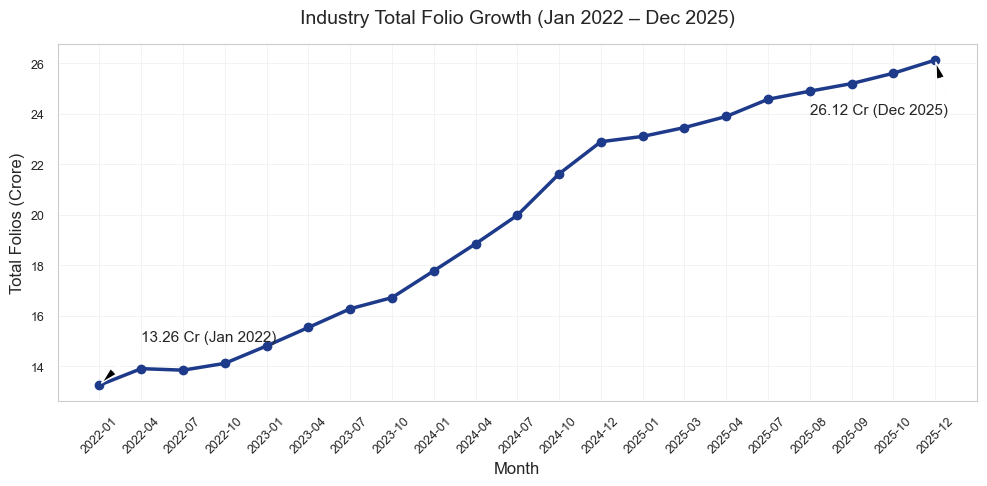

In [17]:
# Chart 15: Folio Count Growth (Jan 2022 to Dec 2025) [Matplotlib]
query_folios = "SELECT month, total_folios_crore, equity_folios_crore, debt_folios_crore, hybrid_folios_crore, others_folios_crore FROM industry_folio_count"
df_folios = pd.read_sql_query(query_folios, conn)
df_folios = df_folios.sort_values('month').reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(df_folios['month'], df_folios['total_folios_crore'], marker='o', color=PRIMARY_COLOR, linewidth=2.5)
plt.title('Industry Total Folio Growth (Jan 2022 – Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.xticks(rotation=45)

# Highlight milestones
plt.annotate('13.26 Cr (Jan 2022)', xy=(0, 13.26), xytext=(1, 15),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.annotate('26.12 Cr (Dec 2025)', xy=(len(df_folios)-1, 26.12), xytext=(len(df_folios)-4, 24),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart15_folio_growth.png", dpi=300)
plt.show()

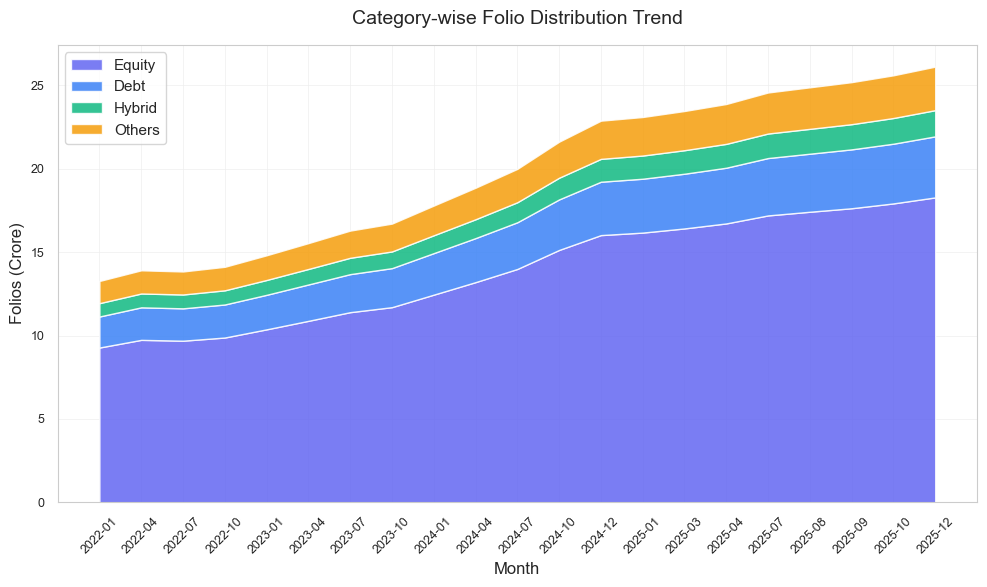

In [18]:
# Chart 16: Category-wise Folio Growth Stacked Area Chart [Matplotlib]
plt.figure(figsize=(10, 6))
plt.stackplot(df_folios['month'],
              df_folios['equity_folios_crore'],
              df_folios['debt_folios_crore'],
              df_folios['hybrid_folios_crore'],
              df_folios['others_folios_crore'],
              labels=['Equity', 'Debt', 'Hybrid', 'Others'],
              colors=['#6366F1', '#3B82F6', '#10B981', '#F59E0B'], alpha=0.85)
plt.title('Category-wise Folio Distribution Trend', fontsize=14, pad=15)
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart16_folio_category_stacked.png", dpi=300)
plt.show()

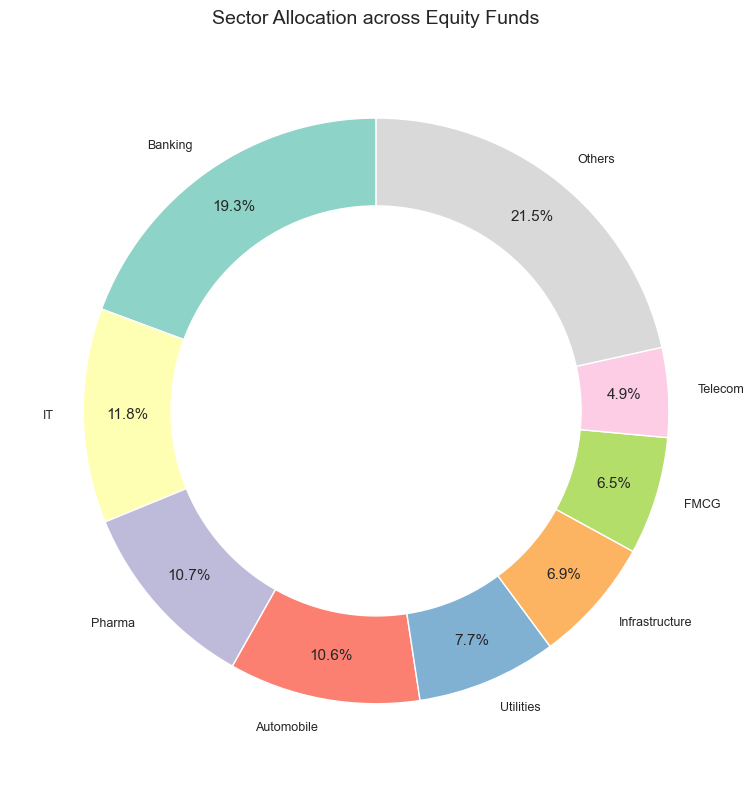

In [19]:
# Chart 17: Sector Allocation Donut Chart for Equity Funds [Matplotlib]
query_holdings = """
SELECT ph.sector, SUM(ph.market_value_cr) as total_mkt_val
FROM portfolio_holdings ph
JOIN fund_master f ON ph.amfi_code = f.amfi_code
WHERE f.category = 'Equity'
GROUP BY ph.sector
ORDER BY total_mkt_val DESC
"""
df_holdings = pd.read_sql_query(query_holdings, conn)

# Top 8 sectors and group others
top_sectors = df_holdings.head(8).copy()
others_val = df_holdings.iloc[8:]['total_mkt_val'].sum()
others_row = pd.DataFrame([{'sector': 'Others', 'total_mkt_val': others_val}])
df_donut = pd.concat([top_sectors, others_row], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(df_donut['total_mkt_val'], labels=df_donut['sector'], autopct='%1.1f%%',
        colors=sns.color_palette('Set3'), startangle=90, pctdistance=0.85)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation across Equity Funds', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "chart17_sector_allocation_donut.png", dpi=300)
plt.show()

### Key Findings - Section 3 & 4: Demographics, Folios & Portfolios
* **Insight 10:** Total mutual fund folios grew from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025, driven almost entirely by the growth in Equity category folios (Refer to Chart 15 and Chart 16).

In [20]:
# Close connection
conn.close()
print("Database connection closed successfully!")

Database connection closed successfully!
